Epoch 0, Loss: 1.98001e-01, IC: 1.97289e-01, PDE: 7.11688e-04
Epoch 100, Loss: 6.89746e-03, IC: 5.59411e-03, PDE: 1.30335e-03
Epoch 200, Loss: 3.43424e-03, IC: 2.74556e-03, PDE: 6.88679e-04
Epoch 300, Loss: 3.04093e-03, IC: 2.67950e-03, PDE: 3.61426e-04
Epoch 400, Loss: 2.86707e-03, IC: 2.65673e-03, PDE: 2.10340e-04
Epoch 500, Loss: 2.79882e-03, IC: 2.64617e-03, PDE: 1.52650e-04
Epoch 600, Loss: 2.75536e-03, IC: 2.63538e-03, PDE: 1.19979e-04
Epoch 700, Loss: 2.72274e-03, IC: 2.62544e-03, PDE: 9.73047e-05
Epoch 800, Loss: 2.69869e-03, IC: 2.61684e-03, PDE: 8.18536e-05
Epoch 900, Loss: 2.68154e-03, IC: 2.60957e-03, PDE: 7.19687e-05


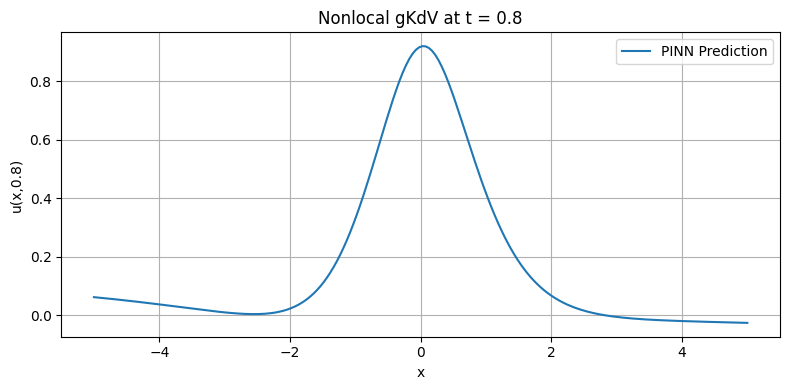

In [ ]:
# PINN implementation for nonlocal gKdV with noisy initial data and adaptive sampling
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

#from scipy.interpolate import interp1d

# Set seed
np.random.seed(0)
torch.manual_seed(0)

# Domain
x_min, x_max = -5, 5
t_min, t_max = 0, 1

# Network architecture
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.hidden = nn.ModuleList()
        for i in range(len(layers)-1):
            self.hidden.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x, t):
        X = torch.cat((x, t), dim=1)
        for layer in self.hidden[:-1]:
            X = torch.tanh(layer(X))
        return self.hidden[-1](X)

# Kernel for nonlocal term
def kernel(x):
    return torch.exp(-torch.abs(x))

# Residual for nonlocal gKdV
def residual(model, x, t, x_quad, dx_quad, gamma=0.1):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), create_graph=True)[0]

    # Nonlocal term via quadrature
    with torch.no_grad():
        u_all = model(x_quad, t[:1].repeat(x_quad.shape[0], 1)).detach().reshape(-1)
        nonlocal_term = []
        for xi in x:
            K = kernel(xi - x_quad.squeeze())
            conv = torch.sum(K * u_all) * dx_quad
            nonlocal_term.append(conv)
        nonlocal_term = torch.tensor(nonlocal_term).reshape(-1, 1)

    return u_t + u**2 * u_x + 0.1 * u_xxx + gamma * nonlocal_term

# Training data
N0 = 50
Nf = 1000
x0 = np.linspace(x_min, x_max, N0).reshape(-1, 1)
u0 = 1 / np.cosh(x0)**2 + 0.05 * np.random.randn(*x0.shape)

X_f = np.random.uniform(x_min, x_max, (Nf, 1))
T_f = np.random.uniform(t_min, t_max, (Nf, 1))

# Quadrature points
x_quad = torch.linspace(x_min, x_max, 200).reshape(-1, 1)
dx_quad = (x_max - x_min) / 200

# Convert to tensors
x0_tensor = torch.tensor(x0, dtype=torch.float32)
t0_tensor = torch.zeros_like(x0_tensor)
u0_tensor = torch.tensor(u0, dtype=torch.float32)

x_f_tensor = torch.tensor(X_f, dtype=torch.float32)
t_f_tensor = torch.tensor(T_f, dtype=torch.float32)

x_quad_tensor = x_quad.float()

# Model setup
layers = [2, 32, 32, 32, 1]
model = PINN(layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training
for epoch in range(1000):
    optimizer.zero_grad()

    u_pred0 = model(x0_tensor, t0_tensor)
    loss_ic = torch.mean((u_pred0 - u0_tensor)**2)

    res = residual(model, x_f_tensor, t_f_tensor, x_quad_tensor, dx_quad)
    loss_pde = torch.mean(res**2)

    loss = loss_ic + loss_pde
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.5e}, IC: {loss_ic.item():.5e}, PDE: {loss_pde.item():.5e}")

# Evaluation
x_eval = torch.linspace(x_min, x_max, 200).reshape(-1, 1)
t_eval = torch.full_like(x_eval, 0.8)
u_eval = model(x_eval, t_eval).detach().numpy()

# Plot
plt.figure(figsize=(8,4))
plt.plot(x_eval.numpy(), u_eval, label='PINN Prediction')
plt.title('Nonlocal gKdV at t = 0.8')
plt.xlabel('x')
plt.ylabel('u(x,0.8)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def simple_interp1d(x, y, kind="linear"):
    return lambda x_new: np.interp(x_new, x, y)


In [ ]:
x = np.linspace(-5, 5, 100)
y = np.sin(x)
interp = simple_interp1d(x, y)
y_new = interp(np.linspace(-4, 4, 50))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

import numpy as np

def interp1d_fallback(x, y, kind="linear"):
    # Soporta solo interpolación lineal como np.interp
    return lambda x_new: np.interp(x_new, x, y)


# Dominio
Nx = 512
L = 5
x = np.linspace(-L, L, Nx)
dx = x[1] - x[0]
k = 2 * np.pi * fftfreq(Nx, d=dx)

# Condición inicial (sin ruido para referencia)
u0 = 1 / np.cosh(x)**2
u = u0.copy()

# Parámetros gKdV
n = 1
beta = 0.1
gamma = 0.1
dt = 1e-4
T = 0.8
Nt = int(T / dt)

# Núcleo no local
X, Y = np.meshgrid(x, x)
K = np.exp(-np.abs(X - Y)) * dx  # matriz para convolución discreta

# Evolución
for _ in range(Nt):
    # FFT y derivadas
    u_hat = fft(u)
    u_x = ifft(1j * k * u_hat).real

    # Evitar overflow por control logarítmico
    u_safe = np.clip(u, -100, 100)
    u_n_u_x = (u_safe**n) * u_x

    # Dispersión implícita
    u_xxx = ifft((1j * k)**3 * u_hat).real

    # Término no local
    Ku = K @ u

    # Residuo completo
    NL = u_n_u_x + beta * u_xxx + gamma * Ku
    NL_hat = fft(NL)

    # Crank–Nicolson para dispersión
    denom = 1 - dt / 2 * 1j * beta * k**3
    numer = fft(u - dt * NL)
    u_hat_new = numer / denom

    u = ifft(u_hat_new).real

# Resultado final espectral
u_spectral = u


In [ ]:
import numpy as np
from numpy.fft import fft, ifft, fftfreq

# Dominio y discretización espectral
L = 5.0
N = 512
x_ref = np.linspace(-L, L, N, endpoint=False)  # malla espectral

dx = x_ref[1] - x_ref[0]
dt = 0.0005
t_final = 0.8
n_steps = int(t_final / dt)

# Condición inicial con ruido
np.random.seed(0)
u0_ref = 1 / np.cosh(x_ref)**2 + 0.05 * np.random.randn(N)


In [ ]:
# Número de onda (k^3 para el término dispersivo)
k = fftfreq(N, d=dx) * 2 * np.pi
k3 = (1j * k)**3

# Inicialización
u = u0_ref.copy()
u_hat = fft(u)

for _ in range(n_steps):
    u = np.real(ifft(u_hat))
    nonlinearity = -0.5j * k * fft(u**2)  # u^2 u_x en Fourier
    dispersion = 0.1 * k3 * u_hat
    u_hat += dt * (nonlinearity - dispersion)

# Solución final
u_ref = np.real(ifft(u_hat))  # u(x, t = 0.8)


<ipython-input-51-ad07566c329e>:11: RuntimeWarning: overflow encountered in square
  nonlinearity = -0.5j * k * fft(u**2)  # u^2 u_x en Fourier
<ipython-input-51-ad07566c329e>:11: RuntimeWarning: invalid value encountered in multiply
  nonlinearity = -0.5j * k * fft(u**2)  # u^2 u_x en Fourier


In [ ]:
# Interpolar solución espectral en malla de la PINN
from scipy.interpolate import interp1d

x_eval_np = x_eval.numpy().flatten()  # malla PINN
interp_ref = interp1d(x_ref, u_ref, kind="cubic", fill_value="extrapolate")
u_ref_interp = interp_ref(x_eval_np)


In [ ]:
print("u_eval min/max:", np.min(u_eval), np.max(u_eval))
print("u_ref_interp min/max:", np.min(u_ref_interp), np.max(u_ref_interp))
print("Any NaNs in u_eval?", np.isnan(u_eval).any())
print("Any NaNs in u_ref_interp?", np.isnan(u_ref_interp).any())
print("Norm denominator:", simpson(u_ref_interp**2, x=x_eval_np))


u_eval min/max: -0.025836734 0.91989636
u_ref_interp min/max: nan nan
Any NaNs in u_eval? False
Any NaNs in u_ref_interp? True
Norm denominator: nan


In [ ]:
x_torch = torch.tensor(x.reshape(-1,1), dtype=torch.float32)
t_torch = torch.full_like(x_torch, 0.8)
u_pinn = model(x_torch, t_torch).detach().numpy().flatten()


In [ ]:
!pip install --upgrade scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [ ]:
!pip uninstall -y scipy
!pip install scipy --upgrade


Found existing installation: scipy 1.15.2
Uninstalling scipy-1.15.2:
  Successfully uninstalled scipy-1.15.2
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.6 MB)


Epoch 0, Loss: 2.6814e+03
Epoch 100, Loss: 7.8610e+02
Epoch 200, Loss: 3.1802e+01
Epoch 300, Loss: 1.4894e+02
Epoch 400, Loss: 1.6851e+03
Epoch 500, Loss: 3.3633e+01
Epoch 600, Loss: 1.1674e+03
Epoch 700, Loss: 2.2044e+03
Epoch 800, Loss: 1.6332e+03
Epoch 900, Loss: 3.5678e+02


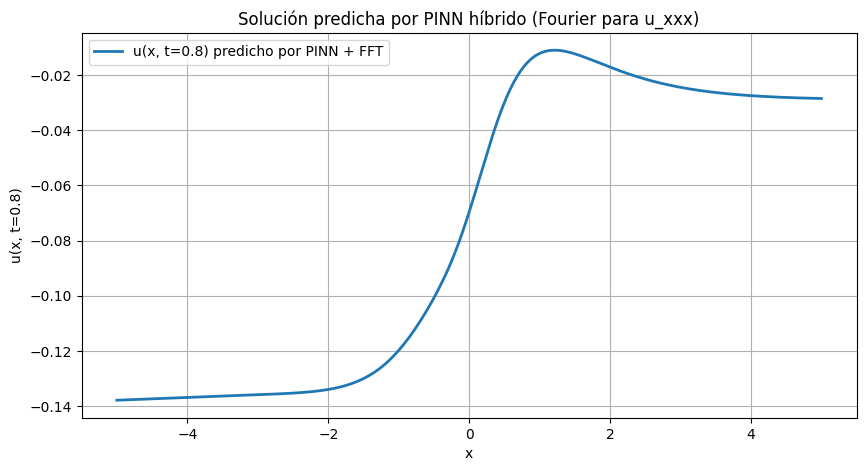

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Dominio espacial y temporal
L = 5
N = 256  # número de puntos espaciales
x = torch.linspace(-L, L, N, dtype=torch.float32).reshape(-1, 1)
x_np = x.detach().numpy().flatten()
dx = x[1] - x[0]

# Definimos t como batch de entrenamiento
t = torch.linspace(0, 1, 100, dtype=torch.float32).reshape(-1, 1)

# Red neuronal básica
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x, t):
        X = torch.cat((x, t), dim=1)
        for layer in self.layers[:-1]:
            X = torch.tanh(layer(X))
        return self.layers[-1](X)

# Derivadas automáticas
def gradients(u, x, order=1):
    for _ in range(order):
        u = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                                create_graph=True)[0]
    return u

# FFT para u_xxx (solo depende de x, no de t)
def compute_uxxx_fft(u, dx):
    u_np = u.detach().cpu().numpy().flatten()
    u_hat = np.fft.fft(u_np)
    k = 2 * np.pi * np.fft.fftfreq(len(u_np), d=dx.item())
    uxxx_hat = (1j * k)**3 * u_hat
    uxxx = np.fft.ifft(uxxx_hat).real
    return torch.tensor(uxxx, dtype=torch.float32).reshape(-1, 1)

# Entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN([2, 64, 64, 64, 1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

gamma = 0.01  # Coeficiente de dispersión

for epoch in range(1000):
    optimizer.zero_grad()

    # Muestra aleatoria de tiempo para cada x
    t_sample = t[torch.randint(0, len(t), (N,))].to(device)
    x_batch = x.to(device).requires_grad_()
    t_batch = t_sample.requires_grad_()

    u_pred = model(x_batch, t_batch)
    u_t = gradients(u_pred, t_batch)
    u_x = gradients(u_pred, x_batch)
    u_nonlin = u_pred * u_x

    # Calcula u_xxx con FFT en batch
    u_pred_np = u_pred.detach().cpu()
    u_xxx_fft = compute_uxxx_fft(u_pred_np, dx).to(device)

    residual = u_t + u_nonlin + gamma * u_xxx_fft
    loss = torch.mean(residual**2)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}")


# Evaluar y graficar la solución para un tiempo fijo t = 0.8
model.eval()
t_eval = torch.full_like(x, 0.8).to(device)
x_eval = x.to(device)

with torch.no_grad():
    u_pred = model(x_eval, t_eval).cpu().numpy()

# Gráfica
plt.figure(figsize=(10, 5))
plt.plot(x_np, u_pred, label='u(x, t=0.8) predicho por PINN + FFT', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x, t=0.8)')
plt.title('Solución predicha por PINN híbrido (Fourier para u_xxx)')
plt.legend()
plt.grid(True)
plt.show()


Epoch 0, Loss: 1.2859e-01, Res: 1.40e-04, Fourier: 1.28e-01
Epoch 500, Loss: 1.2627e-03, Res: 4.30e-05, Fourier: 1.22e-03


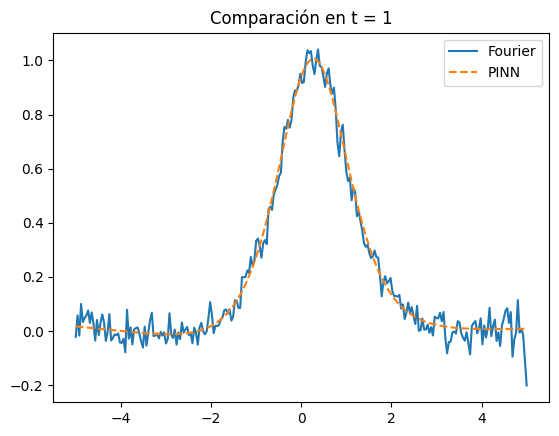

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.interpolate import RegularGridInterpolator

# Parámetros
L = 5.0
N = 256
x = np.linspace(-L, L, N, endpoint=False)
dx = x[1] - x[0]
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
beta = 0.1

# Condición inicial con ruido
np.random.seed(0)
u0 = 1 / np.cosh(x)**2 + 0.05 * np.random.normal(0, 1, size=N)
u = u0.copy()
u_spectral = [u0.copy()]

# Fourier solver (RK + FFT para la parte dispersiva)
k = fftfreq(N, d=dx) * 2 * np.pi
ik3 = (1j * k)**3

for _ in range(nt):
    u_hat = fft(u)
    u = np.real(ifft(u_hat * np.exp(-ik3 * beta * dt)))
    u = u - dt * u * np.gradient(u, dx)
    u_spectral.append(u.copy())

u_spectral = np.array(u_spectral)  # (nt+1, N)
t_vals = np.linspace(0, t_max, nt+1)

# Interpolador
interp_u = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)

def u_fourier_interp(x_input, t_input):
    pts = np.stack([t_input.flatten(), x_input.flatten()], axis=-1)
    return interp_u(pts)

# PINN
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i+1]) if i == len(layers)-2 else
              nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh())
              for i in range(len(layers)-1)]
        )

    def forward(self, x, t):
        input = torch.cat((x, t), dim=1)
        return self.net(input)

def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]

    return u_t + u * u_x + 0.1 * u_xxx

# Entrenamiento
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    optimizer.zero_grad()

    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(
        x_coll.detach().numpy(), t_coll.detach().numpy()
    ), dtype=torch.float32).reshape(-1, 1)

    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + 1.0 * loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Visualización
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('Comparación en t = 1')
plt.show()


Epoch 0, Loss: 1.4653e-01, Res: 1.41e-03, Fourier: 1.45e-01
Epoch 500, Loss: 4.5732e-05, Res: 2.82e-05, Fourier: 1.75e-05
Epoch 1000, Loss: 2.2080e-05, Res: 1.12e-05, Fourier: 1.09e-05
Epoch 1500, Loss: 1.5876e-05, Res: 8.19e-06, Fourier: 7.69e-06
Epoch 2000, Loss: 1.5914e-05, Res: 6.55e-06, Fourier: 9.36e-06
Epoch 2500, Loss: 6.4423e-05, Res: 7.89e-06, Fourier: 5.65e-05
Epoch 3000, Loss: 1.4241e-05, Res: 4.71e-06, Fourier: 9.53e-06
Epoch 3500, Loss: 9.8847e-06, Res: 3.56e-06, Fourier: 6.33e-06


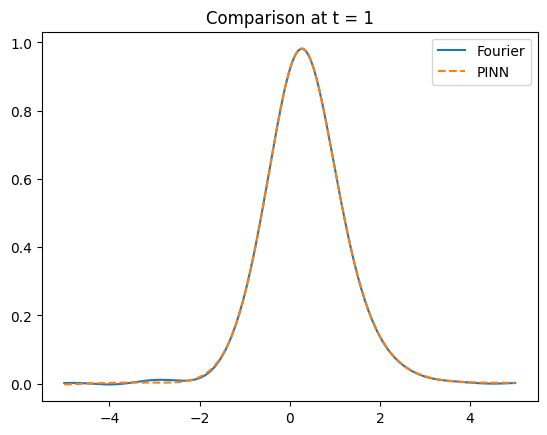

Relative L2 error at t = 1: 7.6714e-03


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.interpolate import RegularGridInterpolator

# Parámetros
L = 5.0
N = 256
x = np.linspace(-L, L, N, endpoint=False)
dx = x[1] - x[0]
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
beta = 0.1

# Condición inicial SIN ruido
u0 = 1 / np.cosh(x)**2
u = u0.copy()
u_spectral = [u0.copy()]

# Fourier solver (RK + FFT para la parte dispersiva)
k = fftfreq(N, d=dx) * 2 * np.pi
ik3 = (1j * k)**3

for _ in range(nt):
    u_hat = fft(u)
    u = np.real(ifft(u_hat * np.exp(-ik3 * beta * dt)))
    u = u - dt * u * np.gradient(u, dx)
    u_spectral.append(u.copy())

u_spectral = np.array(u_spectral)  # (nt+1, N)
t_vals = np.linspace(0, t_max, nt+1)

# Interpolador
interp_u = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)

def u_fourier_interp(x_input, t_input):
    pts = np.stack([t_input.flatten(), x_input.flatten()], axis=-1)
    return interp_u(pts)

# PINN
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i+1]) if i == len(layers)-2 else
              nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh())
              for i in range(len(layers)-1)]
        )

    def forward(self, x, t):
        input = torch.cat((x, t), dim=1)
        return self.net(input)

def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]

    return u_t + u * u_x + 0.1 * u_xxx

# Entrenamiento
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(4000):
    optimizer.zero_grad()

    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(
        x_coll.detach().numpy(), t_coll.detach().numpy()
    ), dtype=torch.float32).reshape(-1, 1)

    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + 1.0 * loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Visualización
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('Comparison at t = 1')
plt.show()

# Cálculo del error relativo L2
numerator = np.sum((u_pinn - u_true)**2)
denominator = np.sum(u_true**2)
rel_L2 = np.sqrt(numerator / denominator)
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


Epoch 0, Loss: 1.4461e-01, Res: 1.82e-03, Fourier: 1.43e-01
Epoch 500, Loss: 1.0458e-04, Res: 8.25e-05, Fourier: 2.21e-05
Epoch 1000, Loss: 3.3676e-05, Res: 2.20e-05, Fourier: 1.16e-05
Epoch 1500, Loss: 1.7058e-05, Res: 9.60e-06, Fourier: 7.45e-06
Epoch 2000, Loss: 1.3367e-05, Res: 7.26e-06, Fourier: 6.11e-06
Epoch 2500, Loss: 5.6087e-05, Res: 7.34e-06, Fourier: 4.87e-05
Epoch 3000, Loss: 3.7813e-05, Res: 7.69e-06, Fourier: 3.01e-05
Epoch 3500, Loss: 9.9921e-05, Res: 8.13e-06, Fourier: 9.18e-05


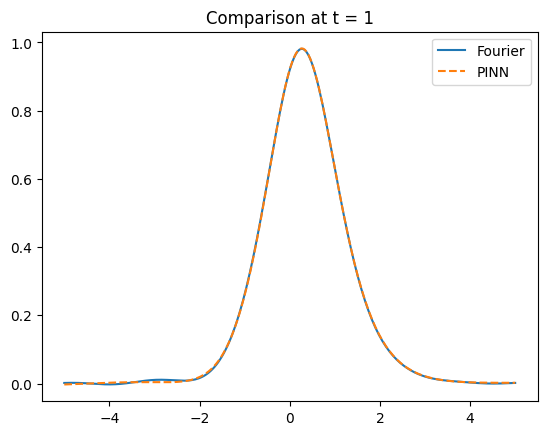

Relative L2 error at t = 1: 7.1926e-03


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.interpolate import RegularGridInterpolator

def initial_condition(x, noise=False):
    u0 = 1 / np.cosh(x)**2
    if noise:
        u0 += 0.05 * np.random.normal(0, 1, size=len(x))
    return u0

def solve_fourier_gkdv(x, u0, dt, nt, gamma):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k)**3
    u = u0.copy()
    sol = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u - dt * u * np.gradient(u, dx)  # para nu = 1, alpha = 1 por defecto
        sol.append(u.copy())
    return np.array(sol)

def u_fourier_interp_func(t_vals, x, u_spectral):
    interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
    return lambda x_input, t_input: interp(np.stack([t_input.flatten(), x_input.flatten()], axis=-1))

class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i+1]) if i == len(layers)-2 else
              nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh())
              for i in range(len(layers)-1)]
        )

    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

def gkdv_residual(model, x, t, alpha=1.0, nu=1.0, gamma=0.1):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# Configuración general
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt+1)
alpha = 1.0
nu = 1.0
gamma = 0.1

u0 = initial_condition(x, noise=False)
u_spectral = solve_fourier_gkdv(x, u0, dt, nt, gamma)
u_fourier_interp = u_fourier_interp_func(t_vals, x, u_spectral)

model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(4000):
    optimizer.zero_grad()
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll, alpha, nu, gamma)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + 1.0 * loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Visualización
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('Comparison at t = 1')
plt.show()

# Error relativo L2
numerator = np.sum((u_pinn - u_true)**2)
denominator = np.sum(u_true**2)
rel_L2 = np.sqrt(numerator / denominator)
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


Epoch 0, Loss: 1.3613e-01, Res: 1.18e-04, Fourier: 1.36e-01
Epoch 500, Loss: 5.7300e-05, Res: 4.05e-05, Fourier: 1.68e-05
Epoch 1000, Loss: 3.0220e-05, Res: 1.87e-05, Fourier: 1.15e-05
Epoch 1500, Loss: 4.6146e-05, Res: 1.10e-05, Fourier: 3.51e-05
Epoch 2000, Loss: 3.2289e-05, Res: 8.29e-06, Fourier: 2.40e-05
Epoch 2500, Loss: 2.4726e-05, Res: 8.20e-06, Fourier: 1.65e-05
Epoch 3000, Loss: 9.2716e-06, Res: 5.93e-06, Fourier: 3.34e-06
Epoch 3500, Loss: 8.5509e-06, Res: 5.73e-06, Fourier: 2.82e-06


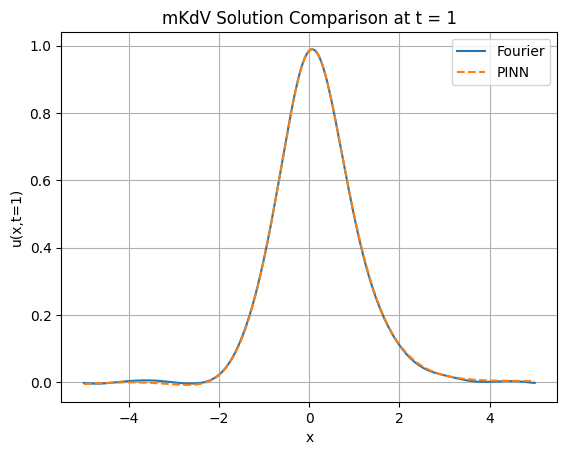

Relative L2 error at t = 1: 8.9786e-03


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.interpolate import RegularGridInterpolator

# ----------- Condición inicial ----------
def initial_condition(x, noise=False):
    u0 = 1 / np.cosh(x)**2
    if noise:
        u0 += 0.05 * np.random.normal(0, 1, size=len(x))
    return u0

# ----------- Solver espectral para gKdV generalizada ----------
def solve_fourier_gkdv(x, u0, dt, nt, alpha=1.0, nu=2.0, gamma=0.1):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k)**3
    u = u0.copy()
    sol = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, dx)
        sol.append(u.copy())
    return np.array(sol)

# ----------- Interpolador espectral ----------
def u_fourier_interp_func(t_vals, x, u_spectral):
    interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
    return lambda x_input, t_input: interp(np.stack([t_input.flatten(), x_input.flatten()], axis=-1))

# ----------- PINN ----------
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i+1]) if i == len(layers)-2 else
              nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh())
              for i in range(len(layers)-1)]
        )

    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# ----------- Residual de la mKdV ----------
def gkdv_residual(model, x, t, alpha=1.0, nu=2.0, gamma=0.1):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# ----------- Configuración general ----------
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt+1)

# ----------- Parámetros para mKdV -----------
alpha = 1.0      # coeficiente no lineal
nu = 2.0         # mKdV: cubic nonlinearity
gamma = 0.1      # dispersión

# ----------- Solución espectral (Fourier) -----------
u0 = initial_condition(x, noise=False)
u_spectral = solve_fourier_gkdv(x, u0, dt, nt, alpha, nu, gamma)
u_fourier_interp = u_fourier_interp_func(t_vals, x, u_spectral)

# ----------- Modelo PINN -----------
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------- Entrenamiento híbrido -----------
for epoch in range(4000):
    optimizer.zero_grad()
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll, alpha, nu, gamma)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + 1.0 * loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# ----------- Visualización -----------
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('mKdV Solution Comparison at t = 1')
plt.xlabel('x')
plt.ylabel('u(x,t=1)')
plt.grid(True)
plt.show()

# ----------- Error relativo L2 -----------
numerator = np.sum((u_pinn - u_true)**2)
denominator = np.sum(u_true**2)
rel_L2 = np.sqrt(numerator / denominator)
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


Epoch 0, Loss: 1.6611e-01, Res: 1.03e-03, Fourier: 1.65e-01
Epoch 500, Loss: 1.5697e-04, Res: 1.08e-04, Fourier: 4.90e-05
Epoch 1000, Loss: 9.4647e-05, Res: 4.70e-05, Fourier: 4.76e-05
Epoch 1500, Loss: 1.4166e-04, Res: 3.35e-05, Fourier: 1.08e-04
Epoch 2000, Loss: 3.3705e-05, Res: 1.91e-05, Fourier: 1.46e-05
Epoch 2500, Loss: 1.3789e-04, Res: 2.10e-05, Fourier: 1.17e-04
Epoch 3000, Loss: 2.5667e-05, Res: 1.27e-05, Fourier: 1.29e-05
Epoch 3500, Loss: 1.7400e-05, Res: 8.69e-06, Fourier: 8.71e-06


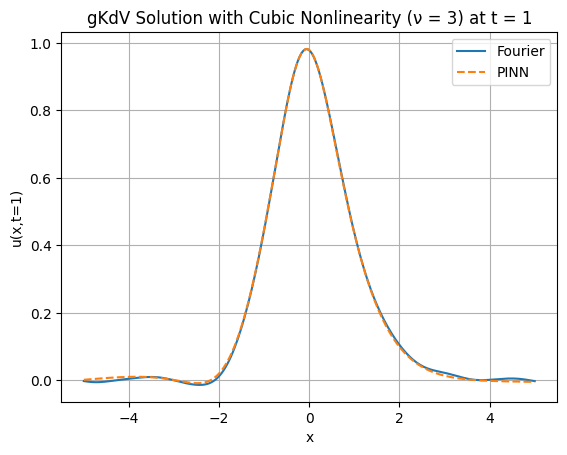

Relative L2 error at t = 1: 1.4083e-02


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.interpolate import RegularGridInterpolator

# ----------- Condición inicial ----------
def initial_condition(x, noise=False):
    u0 = 1 / np.cosh(x)**2
    if noise:
        u0 += 0.05 * np.random.normal(0, 1, size=len(x))
    return u0

# ----------- Solver espectral para gKdV generalizada ----------
def solve_fourier_gkdv(x, u0, dt, nt, alpha=1.0, nu=3.0, gamma=0.1):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k)**3
    u = u0.copy()
    sol = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, dx)
        sol.append(u.copy())
    return np.array(sol)

# ----------- Interpolador espectral ----------
def u_fourier_interp_func(t_vals, x, u_spectral):
    interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
    return lambda x_input, t_input: interp(np.stack([t_input.flatten(), x_input.flatten()], axis=-1))

# ----------- PINN ----------
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i+1]) if i == len(layers)-2 else
              nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh())
              for i in range(len(layers)-1)]
        )

    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# ----------- Residual de la gKdV con no linealidad cúbica ----------
def gkdv_residual(model, x, t, alpha=1.0, nu=3.0, gamma=0.1):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# ----------- Configuración general ----------
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt+1)

# ----------- Parámetros para gKdV cúbica -----------
alpha = 1.0
nu = 3.0  # <- ¡Este es el cambio clave!
gamma = 0.1

# ----------- Solución espectral (Fourier) -----------
u0 = initial_condition(x, noise=False)
u_spectral = solve_fourier_gkdv(x, u0, dt, nt, alpha, nu, gamma)
u_fourier_interp = u_fourier_interp_func(t_vals, x, u_spectral)

# ----------- Modelo PINN -----------
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------- Entrenamiento híbrido -----------
for epoch in range(4000):
    optimizer.zero_grad()
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll, alpha, nu, gamma)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + 1.0 * loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# ----------- Visualización -----------
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('gKdV Solution with Cubic Nonlinearity (ν = 3) at t = 1')
plt.xlabel('x')
plt.ylabel('u(x,t=1)')
plt.grid(True)
plt.show()

# ----------- Error relativo L2 -----------
numerator = np.sum((u_pinn - u_true)**2)
denominator = np.sum(u_true**2)
rel_L2 = np.sqrt(numerator / denominator)
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


In [ ]:
dx = x[1] - x[0]
u_max = np.max(np.abs(u0**nu))
cfl_dt = 0.5 * dx / u_max
print(f"Suggested CFL-like dt for stability: {cfl_dt:.2e}")


Suggested CFL-like dt for stability: 1.95e-02


In [ ]:
# --- Experimento de sensibilidad: profundidad de la red ---
depth_list = [2, 3, 4, 5]
loss_by_depth = []

for depth in depth_list:
    layers = [2] + [50] * depth + [1]
    model = PINN(layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []

    for epoch in range(1000):
        optimizer.zero_grad()
        x_coll = torch.tensor(np.random.uniform(-L, L, (500, 1)), dtype=torch.float32)
        t_coll = torch.tensor(np.random.uniform(0, t_max, (500, 1)), dtype=torch.float32)

        res = gkdv_residual(model, x_coll, t_coll, alpha, nu, gamma)
        loss_res = torch.mean(res**2)

        u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
        u_pred = model(x_coll, t_coll)
        loss_fourier = torch.mean((u_pred - u_fourier)**2)

        loss = loss_res + loss_fourier
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    loss_by_depth.append(loss_history)


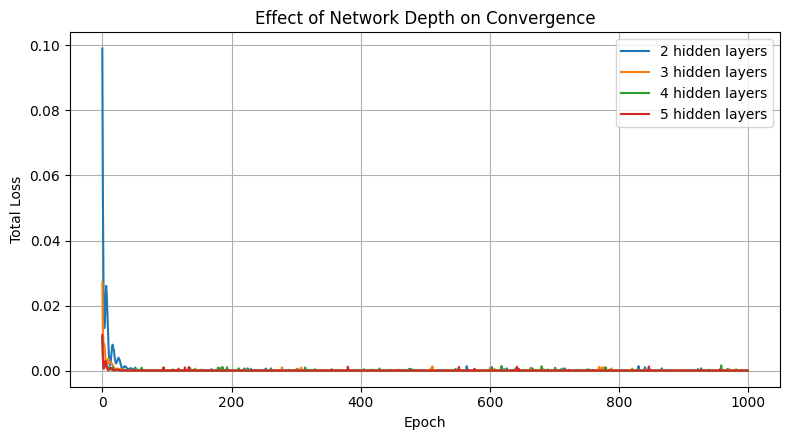

In [ ]:
# --- Gráfico de sensibilidad ---
plt.figure(figsize=(8, 4.5))
for i, depth in enumerate(depth_list):
    plt.plot(loss_by_depth[i], label=f'{depth} hidden layers')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Effect of Network Depth on Convergence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("sensitivity_plot.png", dpi=300)
plt.show()
